# Regressão Regularizada e Regressão Polinomial

## Objetivos da aula

- Entender por que modelos lineares podem falhar por sobreajuste, multicolinearidade ou não linearidade.
- Formular Ridge, Lasso e ElasticNet como mínimos quadrados penalizados.
- Usar `PolynomialFeatures` para modelar relações não lineares por expansão de atributos.
- Implementar tudo em `scikit-learn` com `Pipeline` e validação cruzada.
- Aplicar em dados públicos reais de uma usina termelétrica de ciclo combinado.

In [51]:
from pathlib import Path
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_DIR = Path("dados")
FIG_DIR = Path("figuras_regressao_regularizada_polinomial")
FIG_DIR.mkdir(exist_ok=True)

CCPP_FILE = DATA_DIR / "CCPP.zip"
AIRPASSENGERS_FILE = DATA_DIR / "AirPassengers.csv"

missing = [str(p) for p in [CCPP_FILE, AIRPASSENGERS_FILE] if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Arquivos não encontrados. Coloque o notebook na raiz do projeto e os dados em dados/: "
        + ", ".join(missing)
    )


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## Quando mínimos quadrados fica frágil

- **Sobreajuste:** muitos graus de liberdade para poucos dados.
- **Multicolinearidade:** entradas quase redundantes tornam coeficientes instáveis; pequenas mudanças nos dados podem alterar muito os coeficientes.
- **Escala:** variáveis em unidades diferentes distorcem a penalização.
- **Não linearidade:** a relação real pode não ser bem descrita por uma reta.

Exemplos em Engenharia Elétrica:

- sensores de temperatura em posições próximas;
- corrente, potência e energia acumulada no mesmo sistema;
- ensaio com poucos pontos e muitos atributos extraídos.

## Modelo linear como ponto de partida

Para $n$ amostras e $p$ atributos:

$$
X \in \mathbb{R}^{n \times p}, \qquad y \in \mathbb{R}^n,
$$

$$
\hat{y}_i = \beta_0 + \sum_{j=1}^{p}\beta_j x_{ij}.
$$

Em forma vetorial, com $\boldsymbol{\beta}=[\beta_1,\ldots,\beta_p]^\top$:

$$
\hat{y}=\beta_0\mathbf{1}+X\boldsymbol{\beta}.
$$

Custo não regularizado:

$$
J_{OLS}(\beta_0,\boldsymbol{\beta}) =
\frac{1}{n}\sum_{i=1}^{n}\left(y_i-\beta_0-x_i^\top\boldsymbol{\beta}\right)^2.
$$

Se os coeficientes precisam ser enormes para explicar ruído ou redundância, a previsão tende a variar demais fora do treino.

## Regularização: penalizar complexidade

Ridge, Lasso e ElasticNet partem do erro quadrático e acrescentam penalidades aos coeficientes.

**Ridge:**

$$
J_{Ridge}(\beta_0,\boldsymbol{\beta}) =
\frac{1}{n}\sum_{i=1}^{n}\left(y_i-\beta_0-\sum_{j=1}^{p}\beta_jx_{ij}\right)^2
+\alpha\sum_{j=1}^{p}\beta_j^2.
$$

**Lasso:**

$$
J_{Lasso}(\beta_0,\boldsymbol{\beta}) =
\frac{1}{n}\sum_{i=1}^{n}\left(y_i-\beta_0-\sum_{j=1}^{p}\beta_jx_{ij}\right)^2
+\alpha\sum_{j=1}^{p}|\beta_j|.
$$

**ElasticNet:**

$$
J_{EN}(\beta_0,\boldsymbol{\beta}) =
\frac{1}{n}\sum_{i=1}^{n}\left(y_i-\beta_0-\sum_{j=1}^{p}\beta_jx_{ij}\right)^2
+\alpha\left[\rho\sum_{j=1}^{p}|\beta_j|+(1-\rho)\sum_{j=1}^{p}\beta_j^2\right].
$$

- $\alpha$ controla a força da regularização.
- Ridge = L2; Lasso = L1; ElasticNet = L1 + L2.
- $\rho$ é o `l1_ratio` do ElasticNet.
- Penalizamos $\boldsymbol{\beta}$; o intercepto $\beta_0$ não é penalizado.
- No `scikit-learn`, constantes multiplicativas mudam a escala numérica de $\alpha$.

## Implementação segura: `Pipeline`

A forma segura de implementar pré-processamento e modelo é usar `Pipeline`. O escalonamento é estimado apenas no treino dentro de cada partição da validação cruzada. Isso evita vazamento de dados do teste para o treinamento.

```python
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

preprocess = ColumnTransformer([
    ("num", StandardScaler(), continuous_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
])

ridge = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=10.0))
])

ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
```

## Como ler o `Pipeline`

`ColumnTransformer` aplica transformações diferentes a grupos de colunas.

- Variáveis contínuas passam por `StandardScaler`: média zero e desvio padrão um.
- Variáveis categóricas passam por `OneHotEncoder`: cada categoria vira uma coluna 0/1.
- `Pipeline`: a transformação aprendida no treino é reaplicada ao teste.

Exemplo com `tipo_carga`:

| tipo_carga | R sem drop | L sem drop | NL sem drop | L com `drop="first"` | NL com `drop="first"` |
|---|---:|---:|---:|---:|---:|
| resistiva | 1 | 0 | 0 | 0 | 0 |
| indutiva | 0 | 1 | 0 | 1 | 0 |
| não linear | 0 | 0 | 1 | 0 | 1 |

Com intercepto, manter R, L e NL gera redundância perfeita:

$$
R + L + NL = 1.
$$

A carga resistiva vira a referência; os coeficientes de L e NL medem diferenças em relação a ela.

## Ridge: controlar coeficientes instáveis

Ridge usa penalização L2:

$$
\|\boldsymbol{\beta}\|_2^2=\sum_{j=1}^{p}\beta_j^2.
$$

- Penaliza coeficientes grandes de forma quadrática.
- Reduz todos os coeficientes, mas normalmente não zera atributos.
- Funciona bem quando há variáveis com algum grau de correlação e todas têm algum sinal útil.

Parâmetros podem ser estimados por:

$$
\hat{\boldsymbol{\beta}}_{Ridge} = (X^\top X + n\alpha I)^{-1}X^\top y.
$$

## Lasso: regularização e seleção de variáveis

Lasso usa penalização L1:

$$
\|\boldsymbol{\beta}\|_1=\sum_{j=1}^{p}|\beta_j|.
$$

- Penaliza o valor absoluto dos coeficientes.
- Pode zerar coeficientes: modelo mais esparso.
- Útil quando há muitos atributos candidatos e poucos realmente relevantes.
- Atenção: com variáveis muito correlacionadas, o Lasso pode escolher uma e descartar outra quase equivalente.
- Esparsidade cresce quando a penalização fica mais forte; o $\alpha$ final deve ser escolhido por validação.

## ElasticNet: meio termo prático

- Mistura L1 e L2.
- Herda a possibilidade de seleção de variáveis do Lasso.
- Mantém maior estabilidade em grupos de atributos correlacionados por causa da parcela L2.
- Parâmetros principais: `alpha` e `l1_ratio`.

Regra prática: use ElasticNet quando você espera esparsidade, mas os sensores/atributos aparecem em grupos correlacionados.

## Estudo de caso: usina de ciclo combinado

Dataset: **Combined Cycle Power Plant**, UCI Machine Learning Repository.

- 9568 observações horárias reais de uma usina termelétrica.
- Atributos: temperatura ambiente, vácuo de exaustão, pressão ambiente e umidade relativa.
- Alvo: potência elétrica líquida produzida pela usina, em MW.
- Problema: prever geração líquida a partir de condições operacionais e ambientais.
- Problema de Regressão Estática Supervisionada.

In [68]:
def load_power_plant_data(path=CCPP_FILE):
    rename = {
        "AT": "ambient_temperature",
        "V": "exhaust_vacuum",
        "AP": "ambient_pressure",
        "RH": "relative_humidity",
        "PE": "net_power_output",
    }
    with zipfile.ZipFile(path) as archive:
        with archive.open("CCPP/Folds5x2_pp.xlsx") as handle:
            return pd.read_excel(handle).rename(columns=rename)

power = load_power_plant_data()
print(f"Dimensão dos dados: {power.shape[0]} linhas e {power.shape[1]} colunas")

Dimensão dos dados: 9568 linhas e 5 colunas


## O que os dados já indicam?

Temperatura e vácuo têm forte correlação negativa com a potência líquida; também são correlacionados entre si. A matriz orienta a escolha inicial de variáveis e alerta para multicolinearidade.

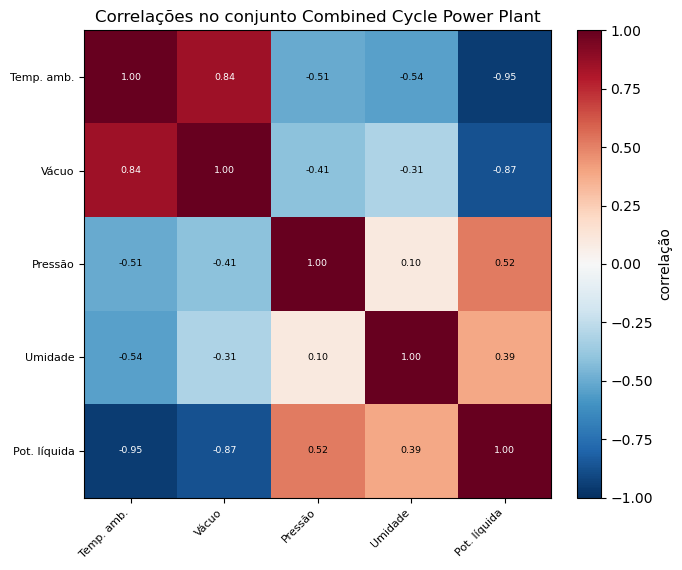

In [53]:
continuous_cols = [
    "ambient_temperature",
    "exhaust_vacuum",
    "ambient_pressure",
    "relative_humidity",
]
categorical_cols = []
feature_cols = continuous_cols + categorical_cols
target_col = "net_power_output"

corr = power[continuous_cols + [target_col]].corr(numeric_only=True)
labels = ["Temp. amb.", "Vácuo", "Pressão", "Umidade", "Pot. líquida"]

fig, ax = plt.subplots(figsize=(7.4, 5.8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) > 0.65 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=6.8, color=color)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlação")
ax.set_title("Correlações no conjunto Combined Cycle Power Plant")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlacao_ccpp.png", dpi=180, bbox_inches="tight")
plt.show()

## Como ler a matriz de correlação

- Cada célula mostra a correlação linear de Pearson entre duas variáveis contínuas, no intervalo $[-1,1]$.
- Valores perto de $+1$ indicam que as variáveis crescem juntas; perto de $-1$, uma cresce quando a outra diminui.
- Valores perto de zero indicam pouca relação linear, mas não descartam relação não linear.
- Correlações fortes entre atributos indicam multicolinearidade: mínimos quadrados pode produzir coeficientes instáveis.

Aqui a matriz sugere quais variáveis devem entrar no modelo e por que regularização pode ser útil. Ela não prova causalidade e não substitui validação em dados de teste.

## Definindo um PreProcessor

```python
polynomial_preprocessor = ColumnTransformer([
    ("num_poly", Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())]), continuous_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
])
```

- `continuous_cols`: entram em `PolynomialFeatures` e depois em `StandardScaler`.
- Grau 2 cria termos lineares, quadráticos e interações: $AT$, $AT^2$, $AT\cdot V$, etc.
- `include_bias=False`: não cria coluna constante; o intercepto fica em $\beta_0$.
- `categorical_cols`: não recebem potências; são tratadas com `OneHotEncoder`.

In [54]:
linear_preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
    ],
    verbose_feature_names_out=False,
)

polynomial_preprocessor = ColumnTransformer(
    [
        (
            "num_poly",
            Pipeline([
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
            ]),
            continuous_cols,
        ),
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
    ],
    verbose_feature_names_out=False,
)

## Experimento: `Poly2 + Ridge`

```python
poly2_grid = GridSearchCV(
    Pipeline([
        ("preprocess", polynomial_preprocessor),
        ("model", Ridge())
    ]),
    {"model__alpha": np.logspace(-3, 3, 25)},
    cv=5,
    scoring="neg_root_mean_squared_error"
)
```

`PolynomialFeatures` cria termos quadráticos e interações; Ridge controla coeficientes grandes por L2. O `GridSearchCV` testa 25 valores de $\alpha$, usa `cv=5` e seleciona a configuração pelo RMSE negativo.

## Experimento: `Lasso seletor`

```python
lasso_probe = Pipeline([
    ("preprocess", polynomial_preprocessor),
    ("model", Lasso(alpha=0.08,
                    max_iter=20000,
                    tol=1e-3))
])
```

O Lasso usa penalização L1 e pode zerar coeficientes. Depois da expansão polinomial, isso ajuda a identificar quais termos lineares, quadráticos e interações ficaram ativos para o valor escolhido de $\alpha$.

## Experimento: `Ridge após Lasso`

```python
from sklearn.feature_selection import SelectFromModel

lasso_selector = SelectFromModel(
    Lasso(alpha=0.08, max_iter=20000, tol=1e-3),
    threshold=1e-8
)

ridge_after_lasso = Pipeline([
    ("preprocess", polynomial_preprocessor),
    ("select", lasso_selector),
    ("model", Ridge(alpha=10.0))
])
```

Primeiro, o Lasso seleciona termos da expansão polinomial. Depois, o Ridge é reajustado usando apenas esses termos, buscando um modelo mais simples e estável.

## O que o `GridSearchCV` faz?

- Testa uma grade de hiperparâmetros definida pelo usuário, por exemplo vários valores de $\alpha$.
- Para cada valor, faz validação cruzada no conjunto de treino.
- Usa a métrica escolhida para selecionar a melhor configuração.
- No `scikit-learn`, métricas de erro aparecem com sinal negativo porque a busca sempre maximiza o `scoring`.

Neste estudo de caso, usamos `GridSearchCV` para escolher $\alpha$ em Ridge, ElasticNet e Poly2 + Ridge. Depois comparamos essas técnicas com Lasso seletor e Ridge após seleção por Lasso no mesmo conjunto de teste.

In [55]:
X = power[feature_cols]
y = power[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

LASSO_SELECTION_ALPHA = 0.08

models_ccpp = {
    "Linear original": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LinearRegression()),
    ]),
    "Ridge original": GridSearchCV(
        Pipeline([("preprocess", linear_preprocessor), ("model", Ridge())]),
        {"model__alpha": np.logspace(-3, 3, 25)},
        cv=5,
        scoring="neg_root_mean_squared_error",
    ),
    "Lasso seletor": Pipeline([
        ("preprocess", polynomial_preprocessor),
        ("model", Lasso(alpha=LASSO_SELECTION_ALPHA, max_iter=20000, tol=1e-3)),
    ]),
    "Ridge após Lasso": Pipeline([
        ("preprocess", polynomial_preprocessor),
        (
            "select",
            SelectFromModel(
                Lasso(alpha=LASSO_SELECTION_ALPHA, max_iter=20000, tol=1e-3),
                threshold=1e-8,
            ),
        ),
        ("model", Ridge(alpha=10.0)),
    ]),
    "Poly2 todos + Ridge": GridSearchCV(
        Pipeline([
            ("preprocess", polynomial_preprocessor),
            ("model", Ridge()),
        ]),
        {"model__alpha": np.logspace(-3, 3, 25)},
        cv=5,
        scoring="neg_root_mean_squared_error",
    ),
    "ElasticNet": GridSearchCV(
        Pipeline([("preprocess", linear_preprocessor), ("model", ElasticNet(max_iter=50000))]),
        {
            "model__alpha": np.logspace(-4, 1, 18),
            "model__l1_ratio": [0.2, 0.5, 0.8],
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
    ),
}

fitted_ccpp = {}
rows = []
for name, estimator in models_ccpp.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_test)
    rows.append({
        "modelo": name,
        "RMSE": rmse(y_test, pred),
        "MAE": float(mean_absolute_error(y_test, pred)),
        "R2": float(r2_score(y_test, pred)),
    })
    fitted_ccpp[name] = estimator

metrics_ccpp = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
best_ccpp = metrics_ccpp.loc[0, "modelo"]
# Métricas exibidas na seção de comparação de desempenho.

## Comparação de desempenho

Nos atributos originais, Ridge e ElasticNet escolheram penalizações fracas; por isso ficam praticamente iguais ao modelo linear.

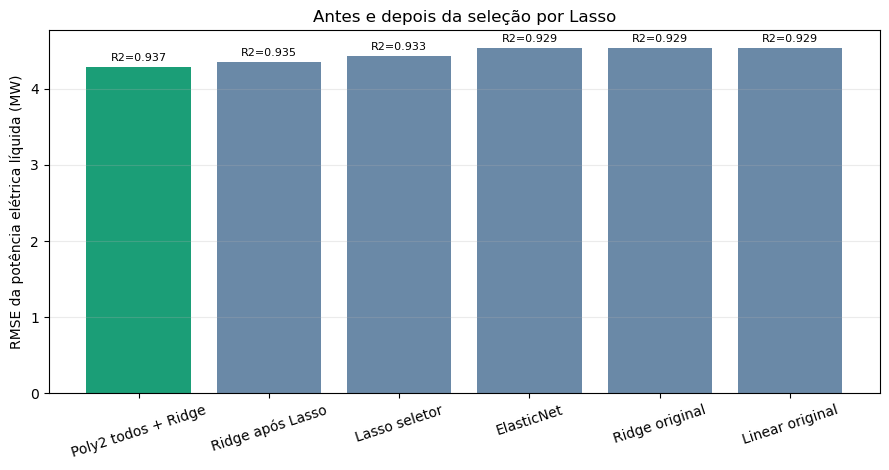

,modelo,RMSE,MAE,R2
0,Poly2 todos + Ridge,4.283,3.344,0.937
1,Ridge após Lasso,4.348,3.437,0.935
2,Lasso seletor,4.427,3.509,0.933
3,ElasticNet,4.537,3.586,0.929
4,Ridge original,4.537,3.586,0.929
5,Linear original,4.537,3.586,0.929


In [56]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))
colors = ["#1b9e77" if i == 0 else "#6a89a7" for i in range(len(metrics_ccpp))]
ax.bar(metrics_ccpp["modelo"], metrics_ccpp["RMSE"], color=colors)
ax.set_ylabel("RMSE da potência elétrica líquida (MW)")
ax.set_title("Antes e depois da seleção por Lasso")
ax.tick_params(axis="x", rotation=18)
ax.grid(axis="y", alpha=0.25)
for i, (_, row) in enumerate(metrics_ccpp.iterrows()):
    ax.text(i, row["RMSE"] + 0.08, f"R2={row["R2"]:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "comparacao_modelos.png", dpi=180, bbox_inches="tight")
plt.show()

display(metrics_ccpp.style.format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.3f}"}))

## Seleção por Lasso depois da expansão polinomial

O gráfico abaixo corresponde ao uso do Lasso como seletor de termos lineares, quadráticos e interações para o valor escolhido de $\alpha$.

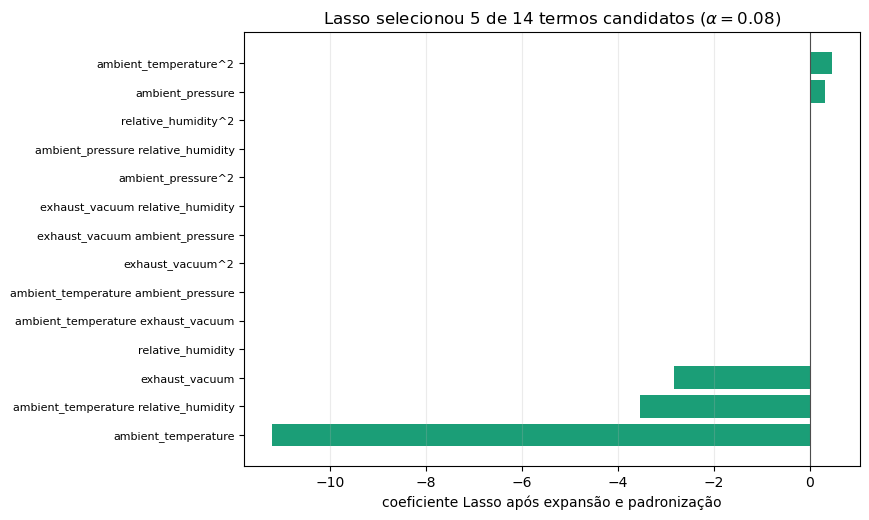

In [65]:
lasso_pipe = fitted_ccpp["Lasso seletor"]
feature_names = lasso_pipe.named_steps["preprocess"].get_feature_names_out()
coef = lasso_pipe.named_steps["model"].coef_

coefs = (
    pd.DataFrame({"termo": feature_names, "coeficiente": coef})
    .assign(selecionado=lambda d: d["coeficiente"].abs() > 1e-8)
    .sort_values("coeficiente")
)
selected_count = int(coefs["selecionado"].sum())

y_pos = np.arange(len(coefs))
colors = np.where(coefs["selecionado"], "#1b9e77", "#c9c9c9")
fig, ax = plt.subplots(figsize=(8.8, 5.3))
ax.barh(y_pos, coefs["coeficiente"], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs["termo"], fontsize=8)
ax.axvline(0, color="0.3", lw=0.8)
ax.set_xlabel("coeficiente Lasso após expansão e padronização")
ax.set_title(
    f"Lasso selecionou {selected_count} de {len(coefs)} termos candidatos "
    + rf"($\alpha={LASSO_SELECTION_ALPHA}$)"
)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "lasso_selecao_variaveis.png", dpi=180, bbox_inches="tight")
plt.show()

## Predição ponto a ponto no teste

Zoom em 120 amostras do teste, ordenadas pelo índice original. Aqui a predição é ponto a ponto: estima-se $PE(t)$ usando variáveis ambientais/operacionais da própria observação $t$, não previsão um passo à frente.

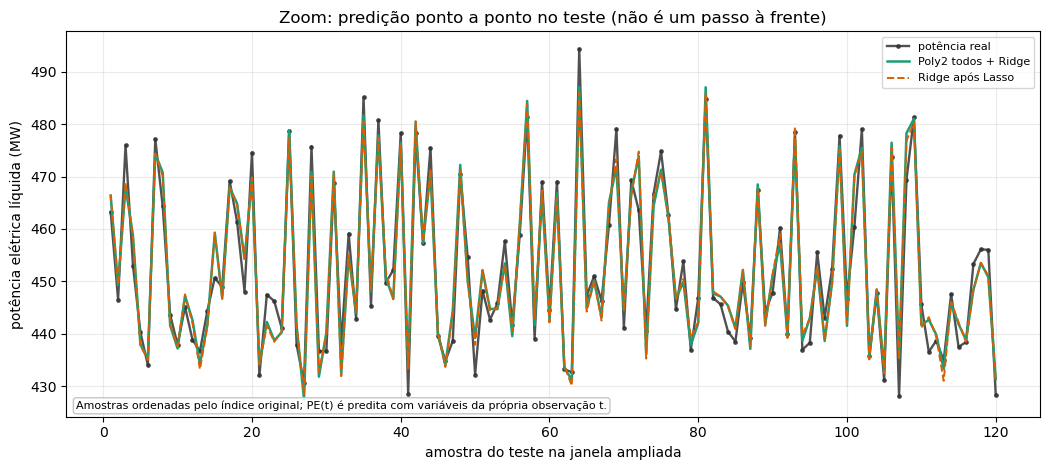

In [67]:
comparison = pd.DataFrame({
    "indice": X_test.index.to_numpy(),
    "real": y_test.to_numpy(),
    best_ccpp: fitted_ccpp[best_ccpp].predict(X_test),
    "Ridge após Lasso": fitted_ccpp["Ridge após Lasso"].predict(X_test),
}).sort_values("indice")
zoom = comparison.head(120).copy()
zoom["amostra_zoom"] = np.arange(1, len(zoom) + 1)

fig, ax = plt.subplots(figsize=(10.6, 4.8))
ax.plot(
    zoom["amostra_zoom"],
    zoom["real"],
    color="0.20",
    lw=1.7,
    marker="o",
    ms=2.4,
    alpha=0.85,
    label="potência real",
)
ax.plot(zoom["amostra_zoom"], zoom[best_ccpp], color="#1b9e77", lw=1.8, label=best_ccpp)
ax.plot(
    zoom["amostra_zoom"],
    zoom["Ridge após Lasso"],
    color="#d95f02",
    lw=1.4,
    linestyle="--",
    label="Ridge após Lasso",
)
ax.set_xlabel("amostra do teste na janela ampliada")
ax.set_ylabel("potência elétrica líquida (MW)")
ax.set_title("Zoom: predição ponto a ponto no teste (não é um passo à frente)")
ax.text(
    0.01,
    0.02,
    "Amostras ordenadas pelo índice original; PE(t) é predita com variáveis da própria observação t.",
    transform=ax.transAxes,
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.75", alpha=0.88),
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "predicao_temporal_ccpp.png", dpi=180, bbox_inches="tight")
plt.show()

## Caminho dos coeficientes

Para as variáveis contínuas, conforme $\alpha$ aumenta, os coeficientes encolhem. Ridge encolhe suavemente; Lasso e ElasticNet podem levar alguns coeficientes a zero.

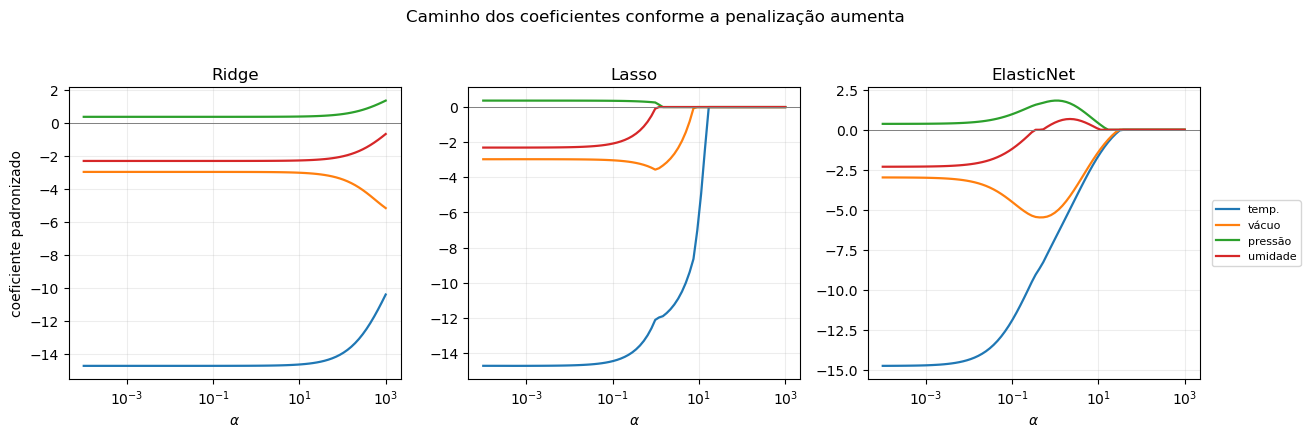

In [59]:
Xs = StandardScaler().fit_transform(power[continuous_cols])
y_all = power[target_col].to_numpy()
alphas = np.logspace(-4, 3, 80)
short_labels = ["temp.", "vácuo", "pressão", "umidade"]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), sharex=True)
estimators = [
    ("Ridge", Ridge, {}),
    ("Lasso", Lasso, {"max_iter": 50000}),
    ("ElasticNet", ElasticNet, {"l1_ratio": 0.5, "max_iter": 50000}),
]
for ax, (title, cls, kwargs) in zip(axes, estimators):
    coefs_path = []
    for alpha in alphas:
        model = cls(alpha=alpha, **kwargs)
        model.fit(Xs, y_all)
        coefs_path.append(model.coef_)
    coefs_path = np.asarray(coefs_path)
    for j in range(coefs_path.shape[1]):
        ax.plot(alphas, coefs_path[:, j], lw=1.6, label=short_labels[j])
    ax.set_xscale("log")
    ax.axhline(0, color="0.5", lw=0.7)
    ax.set_title(title)
    ax.set_xlabel(r"$\alpha$")
    ax.grid(alpha=0.22)
axes[0].set_ylabel("coeficiente padronizado")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.suptitle("Caminho dos coeficientes conforme a penalização aumenta", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "caminhos_coeficientes.png", dpi=180, bbox_inches="tight")
plt.show()

## Um pouco mais sobre `PolynomialFeatures`

Em vez de mudar o estimador, mudamos a matriz de atributos:

$$
x=[x_1,x_2]\Rightarrow \phi_2(x)=[x_1,x_2,x_1^2,x_1x_2,x_2^2].
$$

Depois ajustamos:

$$
\hat{y}=\beta_0+\phi_d(x)^\top\boldsymbol{\beta}.
$$

Se $\phi_d(x)$ tem $q$ atributos, o modelo ainda é linear nos parâmetros $\beta_0,\ldots,\beta_q$. A não linearidade aparece nos atributos transformados.

## `PolynomialFeatures` com regularização

Após a transformação, o modelo ajustado é:

$$
\hat{y}=\beta_0+\sum_{\ell=1}^{q}\beta_\ell z_\ell,
\qquad z=\phi_2(x).
$$

- $x$ são os atributos originais; $z$ são os atributos expandidos.
- Para quatro variáveis contínuas, grau 2 gera 14 termos: 4 lineares, 4 quadráticos e 6 interações.
- Esses termos costumam ser correlacionados; por isso Ridge/Lasso/ElasticNet ajudam a controlar variância.
- Regularização é quase obrigatória quando o grau aumenta, pois $q$ cresce rapidamente.

Exemplo: um termo como $AT\cdot V$ permite que o efeito da temperatura ambiente dependa do vácuo de exaustão; $AT^2$ permite curvatura na relação com a potência.

In [60]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(power[continuous_cols])
poly_terms = poly.get_feature_names_out(continuous_cols)
print("Número de termos gerados para quatro variáveis contínuas e grau 2:", len(poly_terms))

Número de termos gerados para quatro variáveis contínuas e grau 2: 14


## Séries temporais como regressão supervisionada

$$
\hat{y}_{t+1}=f(y_t,y_{t-1},y_{t-2},y_{t-11},t,\sin(2\pi m/12),\cos(2\pi m/12)).
$$

- Defasagens representam memória do sistema.
- Tendência e seno/cosseno representam crescimento lento e sazonalidade anual.
- $t$ é o índice temporal da observação: no exemplo, o número do mês na sequência.
- $m$ é o mês do ano: $m=1$ para janeiro, ..., $m=12$ para dezembro.
- A validação deve respeitar o tempo: nada de embaralhar treino e teste.

## Exemplo: passageiros mensais em aviação

Série `AirPassengers`: totais mensais de passageiros internacionais, 1949-1960. Fonte: R `datasets::AirPassengers`.

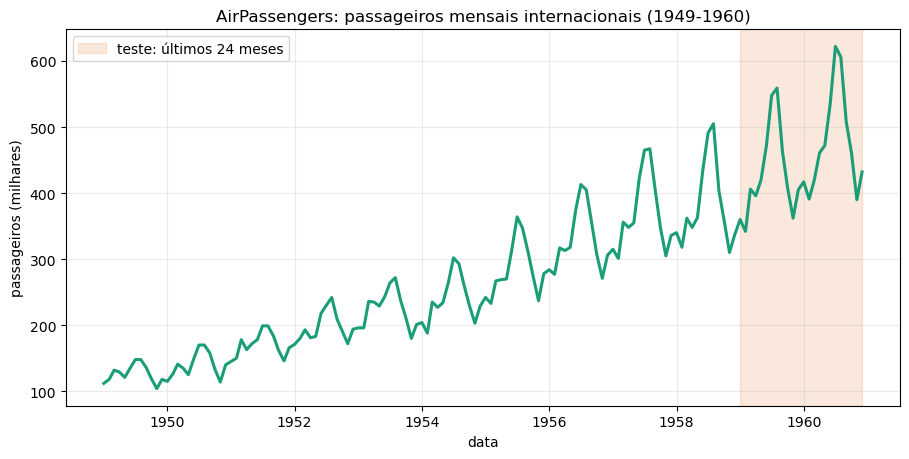

In [61]:
def load_airpassengers(path=AIRPASSENGERS_FILE):
    raw = pd.read_csv(path)
    dates = pd.date_range("1949-01-01", periods=len(raw), freq="MS")
    return pd.DataFrame({
        "date": dates,
        "month_index": np.arange(len(raw)),
        "month": dates.month,
        "passengers": raw["value"].astype(float),
    })


def make_airpassengers_supervised(df):
    data = df.copy()
    for lag in [1, 2, 3, 12]:
        data[f"lag_{lag}"] = data["passengers"].shift(lag)
    data["trend"] = data["month_index"]
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    return data.dropna().reset_index(drop=True)

air = load_airpassengers()

fig, ax = plt.subplots(figsize=(9.2, 4.7))
ax.plot(air["date"], air["passengers"], color="#1b9e77", lw=2.2)
ax.axvspan(
    air["date"].iloc[-24],
    air["date"].iloc[-1],
    color="#d95f02",
    alpha=0.14,
    label="teste: últimos 24 meses",
)
ax.set_title("AirPassengers: passageiros mensais internacionais (1949-1960)")
ax.set_xlabel("data")
ax.set_ylabel("passageiros (milhares)")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "airpassengers_serie.png", dpi=180, bbox_inches="tight")
plt.show()

## Predição um passo à frente

Cada mês do teste usa defasagens reais já observadas. É avaliação um passo à frente, não simulação livre.

## Predição livre no horizonte de teste

Depois do primeiro passo, o modelo usa suas próprias previsões para formar novas defasagens. Erros podem se propagar.

In [62]:
def fit_airpassengers_models(df):
    supervised = make_airpassengers_supervised(df)
    feature_cols_ts = ["lag_1", "lag_2", "lag_3", "lag_12", "trend", "month_sin", "month_cos"]
    target_col_ts = "passengers"
    train = supervised.iloc[:-24].copy()
    test = supervised.iloc[-24:].copy()
    X_train_ts = train[feature_cols_ts]
    y_train_ts = train[target_col_ts]
    X_test_ts = test[feature_cols_ts]
    y_test_ts = test[target_col_ts]
    cv = TimeSeriesSplit(n_splits=5)

    models = {
        "Ridge original": GridSearchCV(
            Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
            {"model__alpha": np.logspace(-3, 3, 25)},
            cv=cv,
            scoring="neg_root_mean_squared_error",
        ),
        "Lasso seletor": GridSearchCV(
            Pipeline([
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                ("model", Lasso(max_iter=100000, tol=1e-4)),
            ]),
            {"model__alpha": np.logspace(-4, 1, 25)},
            cv=cv,
            scoring="neg_root_mean_squared_error",
        ),
        "Ridge após Lasso": GridSearchCV(
            Pipeline([
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                (
                    "select",
                    SelectFromModel(
                        Lasso(alpha=0.1, max_iter=100000, tol=1e-4),
                        threshold=1e-8,
                    ),
                ),
                ("model", Ridge()),
            ]),
            {"model__alpha": np.logspace(-3, 3, 25)},
            cv=cv,
            scoring="neg_root_mean_squared_error",
        ),
        "Poly2 todos + Ridge": GridSearchCV(
            Pipeline([
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                ("model", Ridge()),
            ]),
            {"model__alpha": np.logspace(-3, 3, 25)},
            cv=cv,
            scoring="neg_root_mean_squared_error",
        ),
    }
    order = ["Poly2 todos + Ridge", "Ridge após Lasso", "Lasso seletor", "Ridge original"]

    fitted = {}
    rows_one_step = []
    predictions_one_step = {}
    for name, estimator in models.items():
        estimator.fit(X_train_ts, y_train_ts)
        pred = estimator.predict(X_test_ts)
        rows_one_step.append({
            "modelo": name,
            "RMSE": rmse(y_test_ts, pred),
            "MAE": float(mean_absolute_error(y_test_ts, pred)),
            "R2": float(r2_score(y_test_ts, pred)),
        })
        predictions_one_step[name] = pred
        fitted[name] = estimator

    rows_free = []
    predictions_free = {}
    for name in order:
        history = list(train[target_col_ts].to_numpy())
        preds = []
        for _, row in test.iterrows():
            x_next = pd.DataFrame([{
                "lag_1": history[-1],
                "lag_2": history[-2],
                "lag_3": history[-3],
                "lag_12": history[-12],
                "trend": row["trend"],
                "month_sin": row["month_sin"],
                "month_cos": row["month_cos"],
            }], columns=feature_cols_ts)
            y_hat = float(fitted[name].predict(x_next)[0])
            preds.append(y_hat)
            history.append(y_hat)
        pred = np.asarray(preds)
        predictions_free[name] = pred
        rows_free.append({
            "modelo": name,
            "RMSE": rmse(y_test_ts, pred),
            "MAE": float(mean_absolute_error(y_test_ts, pred)),
            "R2": float(r2_score(y_test_ts, pred)),
        })

    metrics_one_step = pd.DataFrame(rows_one_step).set_index("modelo").loc[order].reset_index()
    metrics_free = pd.DataFrame(rows_free).set_index("modelo").loc[order].reset_index()
    return {
        "train": train,
        "test": test,
        "y_test": y_test_ts,
        "fitted": fitted,
        "metrics_one_step": metrics_one_step,
        "metrics_free": metrics_free,
        "predictions_one_step": predictions_one_step,
        "predictions_free": predictions_free,
    }


ts = fit_airpassengers_models(air)


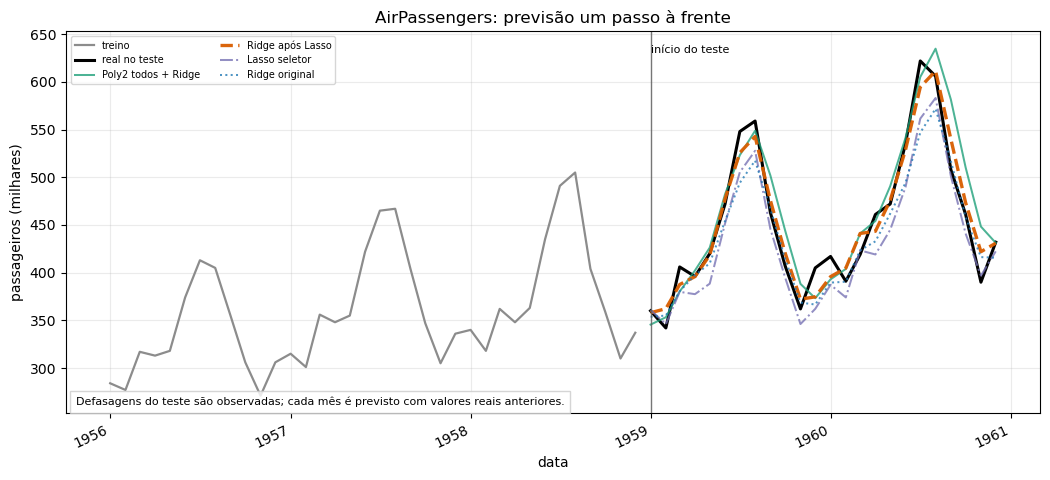

,modelo,RMSE,MAE,R2
0,Poly2 todos + Ridge,29.238,23.400,0.847
1,Ridge após Lasso,17.547,14.509,0.945
2,Lasso seletor,27.619,23.164,0.863
3,Ridge original,27.902,20.888,0.860


In [63]:
def plot_air_forecast(predictions, metrics, filename, title, subtitle):
    train = ts["train"]
    test = ts["test"]
    y_test = ts["y_test"]
    best_name = metrics.sort_values("RMSE").iloc[0]["modelo"]
    styles = {
        "Poly2 todos + Ridge": ("#1b9e77", "-"),
        "Ridge após Lasso": ("#d95f02", "--"),
        "Lasso seletor": ("#7570b3", "-."),
        "Ridge original": ("#1f78b4", ":"),
    }

    fig, ax = plt.subplots(figsize=(10.6, 4.9))
    ax.plot(train["date"].tail(36), train["passengers"].tail(36), color="0.55", lw=1.6, label="treino")
    ax.plot(test["date"], y_test, color="black", lw=2.2, label="real no teste")
    for name in metrics["modelo"].tolist():
        color, linestyle = styles[name]
        lw = 2.4 if name == best_name else 1.45
        alpha = 0.96 if name == best_name else 0.78
        ax.plot(test["date"], predictions[name], color=color, lw=lw, linestyle=linestyle, alpha=alpha, label=name)
    ax.axvline(test["date"].iloc[0], color="0.35", lw=1.0, alpha=0.8)
    ax.text(test["date"].iloc[0], y_test.max() * 1.01, "início do teste", fontsize=8, ha="left", va="bottom")
    ax.set_title(title)
    ax.set_xlabel("data")
    ax.set_ylabel("passageiros (milhares)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="upper left", ncol=2)
    ax.text(
        0.01,
        0.02,
        subtitle,
        transform=ax.transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.82, edgecolor="0.8"),
    )
    fig.autofmt_xdate(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_air_forecast(
    ts["predictions_one_step"],
    ts["metrics_one_step"],
    "airpassengers_um_passo.png",
    "AirPassengers: previsão um passo à frente",
    "Defasagens do teste são observadas; cada mês é previsto com valores reais anteriores.",
)

display(ts["metrics_one_step"].style.format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.3f}"}))

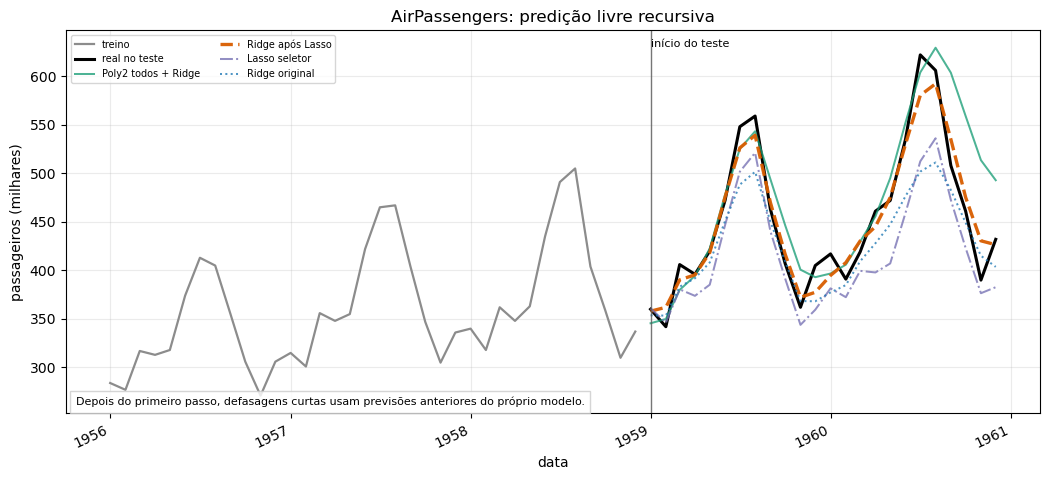

,modelo,RMSE,MAE,R2
0,Poly2 todos + Ridge,43.829,30.378,0.656
1,Ridge após Lasso,18.555,14.864,0.938
2,Lasso seletor,44.677,37.175,0.642
3,Ridge original,41.943,30.426,0.685


In [64]:
plot_air_forecast(
    ts["predictions_free"],
    ts["metrics_free"],
    "airpassengers_predicao_livre.png",
    "AirPassengers: predição livre recursiva",
    "Depois do primeiro passo, defasagens curtas usam previsões anteriores do próprio modelo.",
)

display(ts["metrics_free"].style.format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.3f}"}))

## Referências

- GRUS, Joel. *Data Science do Zero: Noções Fundamentais com Python*. 2ª ed. Rio de Janeiro: Alta Books, 2020.
- TÜFEKCI, P. *Combined Cycle Power Plant* [Dataset]. UCI Machine Learning Repository, 2014. DOI: 10.24432/C5002N.
- PEDREGOSA, F. et al. *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, v. 12, p. 2825–2830, 2011.
- R CORE TEAM. `AirPassengers`: monthly airline passenger numbers 1949–1960. R `datasets` package. CSV via Rdatasets.